# Weather Across the Season at PNC Park

**Goal:** Visualize how temperature, pressure, humidity, and wind speed vary by month at PNC Park (Pittsburgh Pirates) to understand seasonal weather patterns and their potential effects on run scoring.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load league-wide game data and filter to PIT home games
data = pd.read_csv('../../data/league_weather_2021_2025.csv')
pit = data[data['home_team'] == 'PIT'].copy()

# Parse game_date to extract month
pit['game_date'] = pd.to_datetime(pit['game_date'])
pit['month'] = pit['game_date'].dt.month
month_map = {3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct'}
pit['month_name'] = pit['month'].map(month_map)

months = sorted(pit['month'].unique())
month_names = [month_map.get(m, str(m)) for m in months]

print(f"Total PIT home games: {len(pit)}")
print(f"\nGames per month:")
print(pit.groupby('month_name').size().reindex([month_map[m] for m in months]))

/Users/avabrown/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/avabrown/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


Total PIT home games: 405

Games per month:
month_name
Apr    61
May    70
Jun    69
Jul    62
Aug    71
Sep    65
Oct     7
dtype: int64


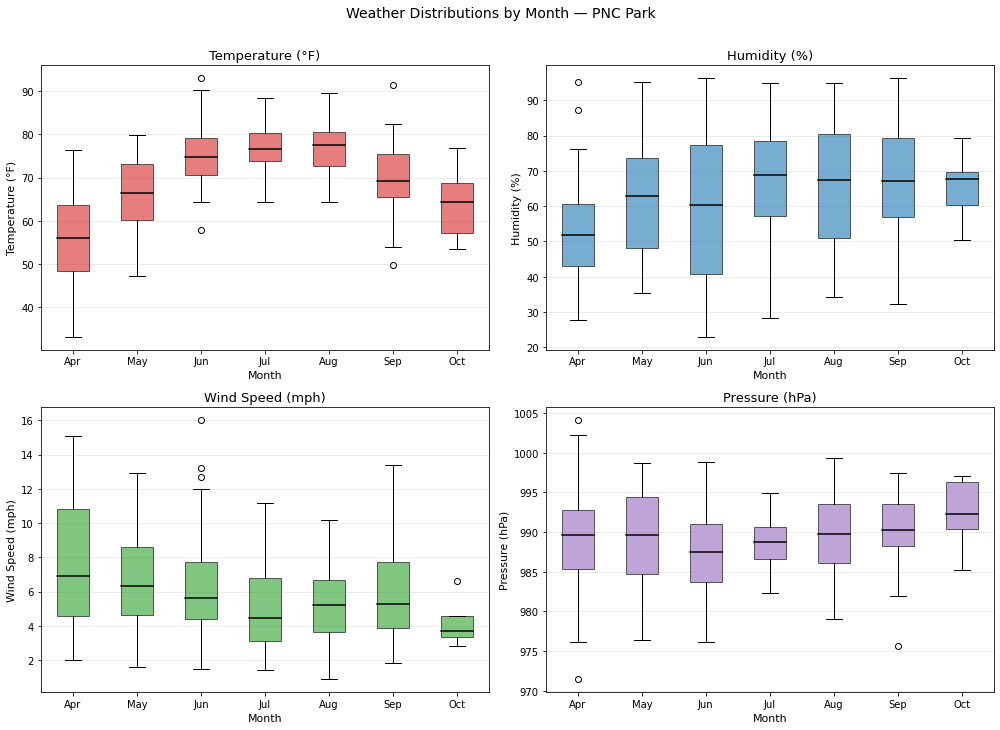

In [2]:
# ============================================================
# Weather Distributions by Month
# ============================================================

weather_vars = {
    'temp_f':   {'label': 'Temperature (°F)', 'color': '#d62728'},
    'rhum':     {'label': 'Humidity (%)',      'color': '#1f77b4'},
    'wspd_mph': {'label': 'Wind Speed (mph)',  'color': '#2ca02c'},
    'pres':     {'label': 'Pressure (hPa)',    'color': '#9467bd'},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, info) in zip(axes.flat, weather_vars.items()):
    box_data = [pit.loc[pit['month'] == m, col].dropna().values for m in months]
    bp = ax.boxplot(box_data, patch_artist=True, labels=month_names,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch in bp['boxes']:
        patch.set_facecolor(info['color'])
        patch.set_alpha(0.6)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel(info['label'], fontsize=11)
    ax.set_title(info['label'], fontsize=13)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle('Weather Distributions by Month — PNC Park', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

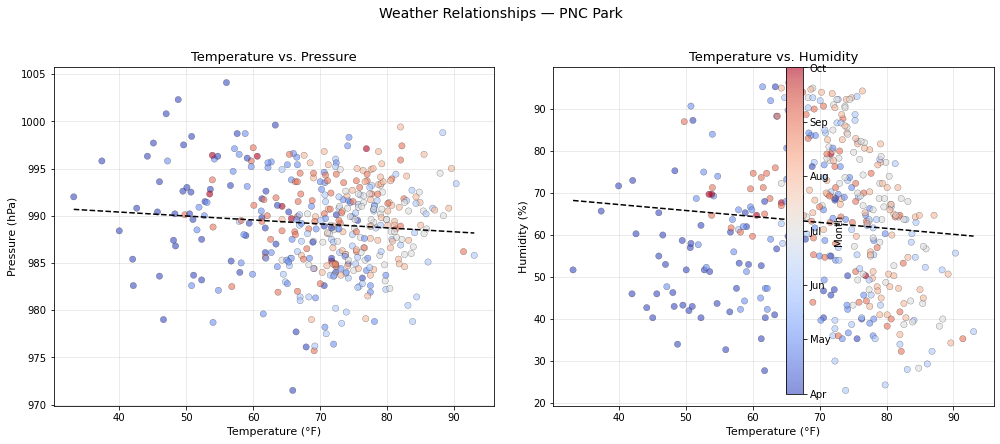

In [3]:
# ============================================================
# Scatter Plots: Temperature vs. Pressure & Temperature vs. Humidity
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Temperature vs. Pressure
ax = axes[0]
scatter = ax.scatter(pit['temp_f'], pit['pres'], c=pit['month'], cmap='coolwarm',
                     alpha=0.6, edgecolors='black', linewidth=0.3, s=40)
z = np.polyfit(pit['temp_f'].dropna(), pit.loc[pit['temp_f'].notna(), 'pres'], 1)
p = np.poly1d(z)
x_line = np.linspace(pit['temp_f'].min(), pit['temp_f'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Temperature (°F)', fontsize=11)
ax.set_ylabel('Pressure (hPa)', fontsize=11)
ax.set_title('Temperature vs. Pressure', fontsize=13)
ax.yaxis.grid(True, alpha=0.3)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Temperature vs. Humidity
ax = axes[1]
scatter = ax.scatter(pit['temp_f'], pit['rhum'], c=pit['month'], cmap='coolwarm',
                     alpha=0.6, edgecolors='black', linewidth=0.3, s=40)
z = np.polyfit(pit['temp_f'].dropna(), pit.loc[pit['temp_f'].notna(), 'rhum'], 1)
p = np.poly1d(z)
ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Temperature (°F)', fontsize=11)
ax.set_ylabel('Humidity (%)', fontsize=11)
ax.set_title('Temperature vs. Humidity', fontsize=13)
ax.yaxis.grid(True, alpha=0.3)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

cbar = fig.colorbar(scatter, ax=axes, label='Month', ticks=months)
cbar.ax.set_yticklabels(month_names)

fig.suptitle('Weather Relationships — PNC Park', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Day vs. Night classification
# ============================================================

# Day games start before 5 PM, night games at 5 PM or later
pit['time_of_day'] = pit['start_hour'].apply(lambda h: 'Day' if h < 17 else 'Night')

print("Game counts by month and time of day:")
print(pit.groupby(['month_name', 'time_of_day']).size().unstack(fill_value=0)
      .reindex([month_map[m] for m in months]))

Game counts by month and time of day:
time_of_day  Day  Night
month_name             
Apr           26     35
May           32     38
Jun           31     38
Jul           23     39
Aug           22     49
Sep           19     46
Oct            3      4


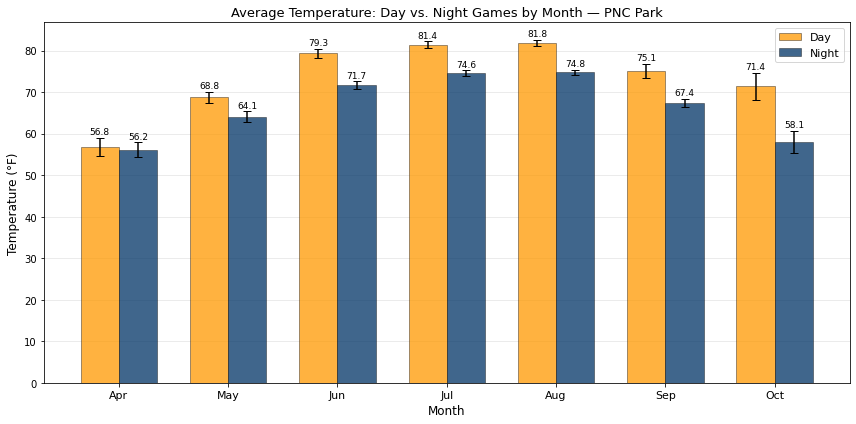

In [5]:
# ============================================================
# Average Temperature: Day vs. Night Games by Month
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(months))
width = 0.35

for i, (label, color) in enumerate([('Day', '#ff9900'), ('Night', '#003366')]):
    subset = pit[pit['time_of_day'] == label]
    grouped = subset.groupby('month')['temp_f']
    means = grouped.mean().reindex(months)
    sems = grouped.sem().reindex(months)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=sems, capsize=4,
           label=label, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    for xi, m in zip(x, means):
        if pd.notna(m):
            ax.text(xi + offset, m + sems.reindex(months).iloc[xi] + 0.3,
                    f'{m:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=11)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Temperature (°F)', fontsize=12)
ax.set_title('Average Temperature: Day vs. Night Games by Month — PNC Park', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

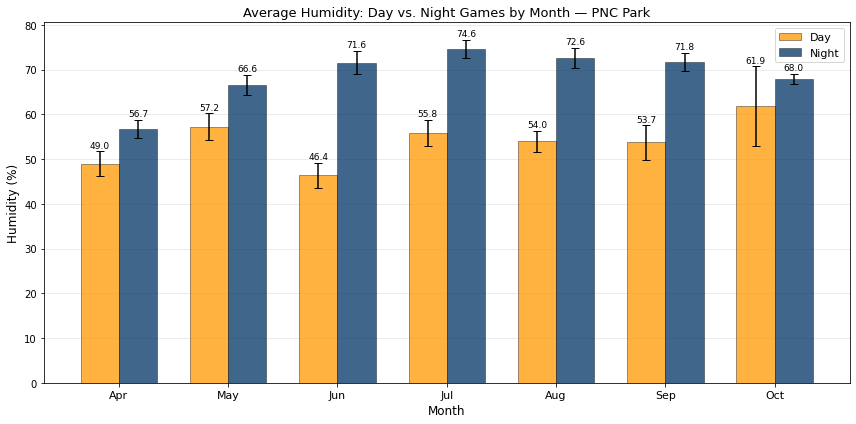

In [6]:
# ============================================================
# Average Humidity: Day vs. Night Games by Month
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(months))
width = 0.35

for i, (label, color) in enumerate([('Day', '#ff9900'), ('Night', '#003366')]):
    subset = pit[pit['time_of_day'] == label]
    grouped = subset.groupby('month')['rhum']
    means = grouped.mean().reindex(months)
    sems = grouped.sem().reindex(months)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=sems, capsize=4,
           label=label, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    for xi, m in zip(x, means):
        if pd.notna(m):
            ax.text(xi + offset, m + sems.reindex(months).iloc[xi] + 0.3,
                    f'{m:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=11)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Humidity (%)', fontsize=12)
ax.set_title('Average Humidity: Day vs. Night Games by Month — PNC Park', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

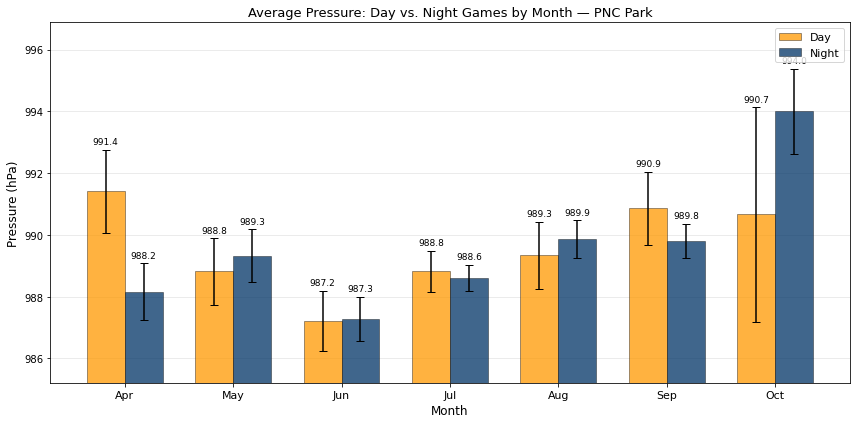

In [7]:
# ============================================================
# Average Pressure: Day vs. Night Games by Month
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(months))
width = 0.35

all_means = []
all_sems = []
for i, (label, color) in enumerate([('Day', '#ff9900'), ('Night', '#003366')]):
    subset = pit[pit['time_of_day'] == label]
    grouped = subset.groupby('month')['pres']
    means = grouped.mean().reindex(months)
    sems = grouped.sem().reindex(months)
    all_means.append(means)
    all_sems.append(sems)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=sems, capsize=4,
           label=label, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    for xi, m in zip(x, means):
        if pd.notna(m):
            ax.text(xi + offset, m + sems.reindex(months).iloc[xi] + 0.1,
                    f'{m:.1f}', ha='center', va='bottom', fontsize=9)

# Zoom y-axis to better show differences
y_min = min(m.min() for m in all_means) - 2
y_max = max(m.max() + s.max() for m, s in zip(all_means, all_sems)) + 1.5
ax.set_ylim(y_min, y_max)

ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=11)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Average Pressure: Day vs. Night Games by Month — PNC Park', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

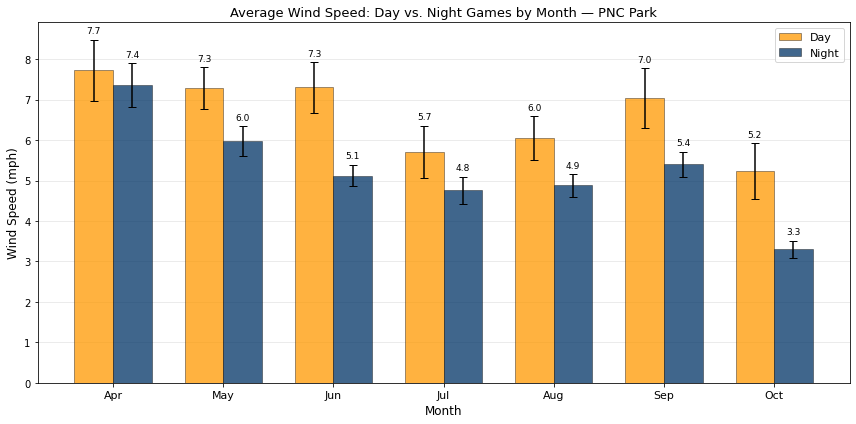

In [8]:
# ============================================================
# Average Wind Speed: Day vs. Night Games by Month
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(months))
width = 0.35

for i, (label, color) in enumerate([('Day', '#ff9900'), ('Night', '#003366')]):
    subset = pit[pit['time_of_day'] == label]
    grouped = subset.groupby('month')['wspd_mph']
    means = grouped.mean().reindex(months)
    sems = grouped.sem().reindex(months)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=sems, capsize=4,
           label=label, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    for xi, m in zip(x, means):
        if pd.notna(m):
            ax.text(xi + offset, m + sems.reindex(months).iloc[xi] + 0.1,
                    f'{m:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=11)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Wind Speed (mph)', fontsize=12)
ax.set_title('Average Wind Speed: Day vs. Night Games by Month — PNC Park', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

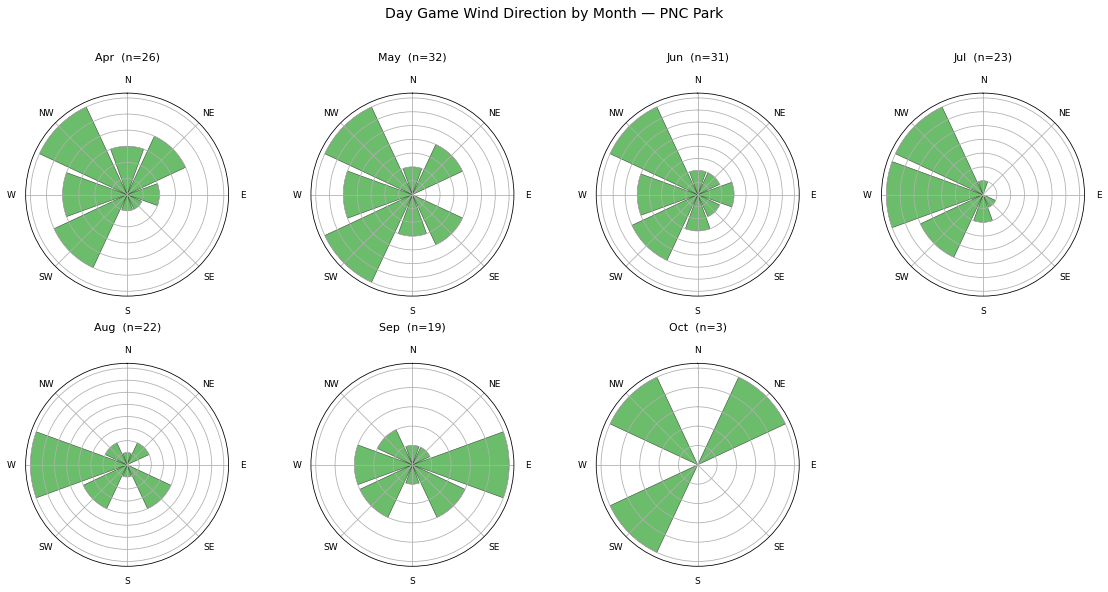

In [9]:
# ============================================================
# Typical Day Game Wind Direction by Month
# ============================================================

# Bin wind directions into 8 compass sectors
def deg_to_compass(deg):
    dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
    idx = int((deg + 22.5) % 360 / 45)
    return dirs[idx]

compass_order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
compass_angles = {d: np.radians(i * 45) for i, d in enumerate(compass_order)}

day_games = pit[pit['time_of_day'] == 'Day'].copy()
day_games['compass'] = day_games['wdir'].apply(deg_to_compass)

active_months = sorted(day_games['month'].unique())
n_months = len(active_months)
cols = min(4, n_months)
rows = int(np.ceil(n_months / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows),
                         subplot_kw=dict(projection='polar'))
if n_months == 1:
    axes = np.array([axes])
axes = axes.flat

for idx, m in enumerate(active_months):
    ax = axes[idx]
    subset = day_games[day_games['month'] == m]
    counts = subset['compass'].value_counts().reindex(compass_order, fill_value=0)
    angles = [compass_angles[d] for d in compass_order]
    bars = ax.bar(angles, counts, width=np.radians(40), alpha=0.7,
                  color='#2ca02c', edgecolor='black', linewidth=0.5)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetagrids([i * 45 for i in range(8)], compass_order, fontsize=9)
    ax.set_title(f'{month_map[m]}  (n={len(subset)})', fontsize=11, pad=15)
    ax.set_yticklabels([])

# Hide unused subplots
for idx in range(n_months, rows * cols):
    axes[idx].set_visible(False)

fig.suptitle('Day Game Wind Direction by Month — PNC Park', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

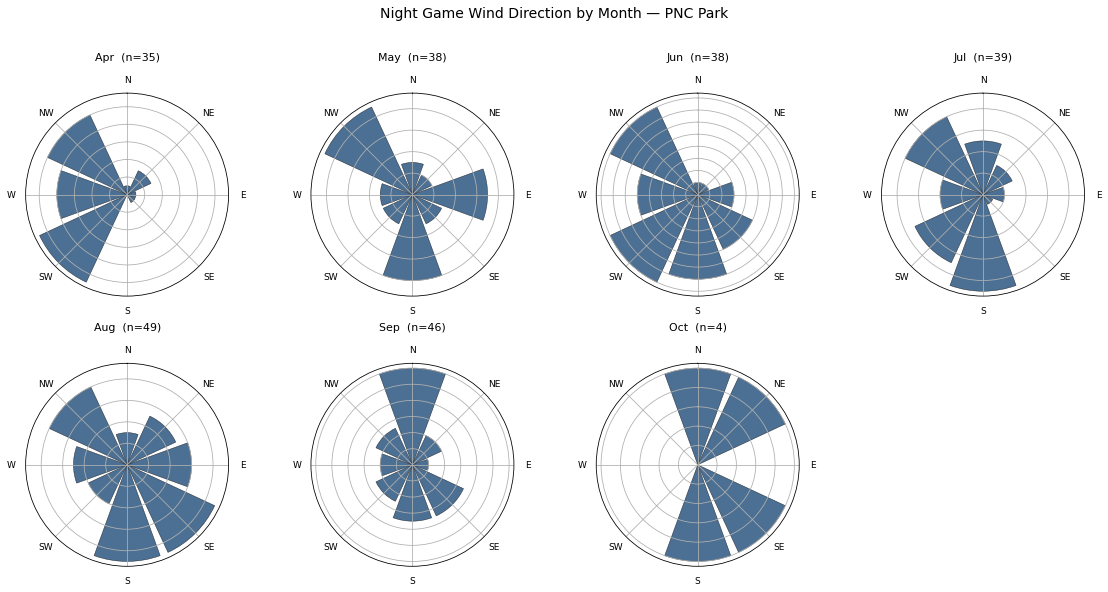

In [10]:
# ============================================================
# Typical Night Game Wind Direction by Month
# ============================================================

night_games = pit[pit['time_of_day'] == 'Night'].copy()
night_games['compass'] = night_games['wdir'].apply(deg_to_compass)

active_months_n = sorted(night_games['month'].unique())
n_months_n = len(active_months_n)
cols = min(4, n_months_n)
rows = int(np.ceil(n_months_n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows),
                         subplot_kw=dict(projection='polar'))
if n_months_n == 1:
    axes = np.array([axes])
axes = axes.flat

for idx, m in enumerate(active_months_n):
    ax = axes[idx]
    subset = night_games[night_games['month'] == m]
    counts = subset['compass'].value_counts().reindex(compass_order, fill_value=0)
    angles = [compass_angles[d] for d in compass_order]
    bars = ax.bar(angles, counts, width=np.radians(40), alpha=0.7,
                  color='#003366', edgecolor='black', linewidth=0.5)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetagrids([i * 45 for i in range(8)], compass_order, fontsize=9)
    ax.set_title(f'{month_map[m]}  (n={len(subset)})', fontsize=11, pad=15)
    ax.set_yticklabels([])

# Hide unused subplots
for idx in range(n_months_n, rows * cols):
    axes[idx].set_visible(False)

fig.suptitle('Night Game Wind Direction by Month — PNC Park', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

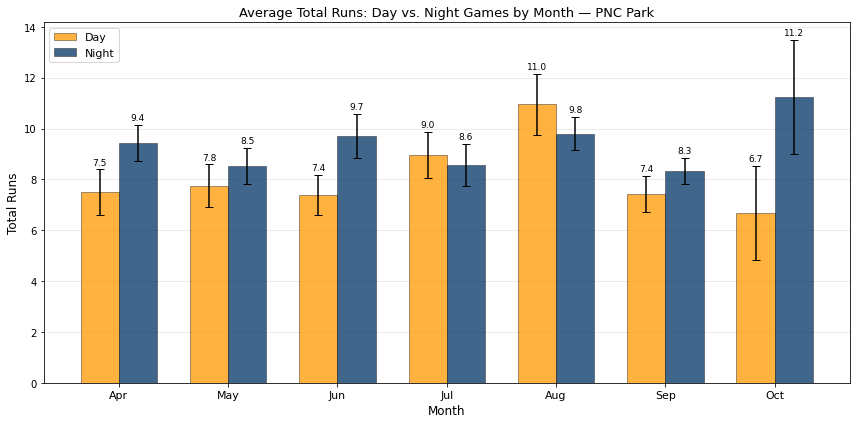

In [11]:
# ============================================================
# Average Total Runs: Day vs. Night Games by Month
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(months))
width = 0.35

for i, (label, color) in enumerate([('Day', '#ff9900'), ('Night', '#003366')]):
    subset = pit[pit['time_of_day'] == label]
    grouped = subset.groupby('month')['total_runs']
    means = grouped.mean().reindex(months)
    sems = grouped.sem().reindex(months)
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=sems, capsize=4,
           label=label, color=color, alpha=0.75, edgecolor='black', linewidth=0.5)
    for xi, m in zip(x, means):
        if pd.notna(m):
            ax.text(xi + offset, m + sems.reindex(months).iloc[xi] + 0.1,
                    f'{m:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=11)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Runs', fontsize=12)
ax.set_title('Average Total Runs: Day vs. Night Games by Month — PNC Park', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Summary Statistics Table
# ============================================================

summary = pit.groupby('month').agg(
    games=('temp_f', 'size'),
    temp_mean=('temp_f', 'mean'),
    temp_std=('temp_f', 'std'),
    rhum_mean=('rhum', 'mean'),
    rhum_std=('rhum', 'std'),
    wspd_mean=('wspd_mph', 'mean'),
    wspd_std=('wspd_mph', 'std'),
    pres_mean=('pres', 'mean'),
    pres_std=('pres', 'std'),
).round(2)

summary.index = [month_map.get(m, str(m)) for m in summary.index]
summary.index.name = 'Month'
summary.columns = ['Games', 'Temp Mean (°F)', 'Temp Std',
                    'Humidity Mean (%)', 'Humidity Std',
                    'Wind Mean (mph)', 'Wind Std',
                    'Pressure Mean (hPa)', 'Pressure Std']
summary

,Games,Temp Mean (°F),Temp Std,Humidity Mean (%),Humidity Std,Wind Mean (mph),Wind Std,Pressure Mean (hPa),Pressure Std
Month,,,,,,,,,
Apr,61,56.45,10.60,53.41,13.33,7.52,3.48,989.55,6.29
May,70,66.27,8.09,62.30,16.21,6.57,2.69,989.10,5.67
Jun,69,75.14,7.07,60.26,20.19,6.10,2.83,987.25,4.89
Jul,62,77.12,5.22,67.65,16.18,5.11,2.56,988.69,2.86
Aug,71,76.98,5.43,66.85,16.78,5.24,2.20,989.71,4.53
Sep,65,69.67,7.91,66.49,16.87,5.88,2.61,990.12,4.19
Oct,7,63.80,8.68,65.34,9.59,4.13,1.28,992.57,4.36
